## Initial Setup
Import dependencies and initialize components

In [2]:
from BitcoinLLMQA_utils import (
    fetch_bitcoin_price,
    update_dataset,
    analyze_data,
    setup_docsgpt,
    handle_query,
    setup_docsgpt,
    add_technical_indicators,
    analyze_time_series,
    create_analysis_plots,
    print_statistical_summary,
    detect_outliers,
    run_bitcoin_chatbot
    
)
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import datetime
from BitcoinLLMQA_utils import backfill_last_n_days_data


In [3]:
# Initialize LLM
llm = setup_docsgpt()

llama_model_load_from_file_impl: using device Metal (Apple M3) - 10922 MiB free
llama_model_loader: loaded meta data with 19 key-value pairs and 291 tensors from llama-2-7b-chat.Q4_K_M.gguf (version GGUF V2)
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = LLaMA v2
llama_model_loader: - kv   2:                       llama.context_length u32              = 4096
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 11008
llama_model_loader: - kv   6:                 llama.rope.dimension_count u32              = 128
llama_model_

## Real-time Data Collection Simulation
Run for 3 intervals (15 minutes total)

In [4]:
df = pd.read_csv('bitcoin_prices.csv')
# df = backfill_last_n_days_data(days=2, interval_minutes=5)
display(df.head())

,timestamp,price,volatility,log_returns
0,2025-05-05 21:27:00,29348.72,NaN,NaN
1,2025-05-05 21:32:00,30835.09,NaN,0.049404
2,2025-05-05 21:37:00,28075.43,NaN,-0.093759
3,2025-05-05 21:42:00,28333.00,NaN,0.009132
4,2025-05-05 21:47:00,31805.88,NaN,0.115624


In [5]:
for i in range(3):
    clear_output(wait=True)
    print(f"Data Collection Cycle {i+1}/3")
    
    # Fetch and update data
    price = fetch_bitcoin_price()
    if price:
        df = update_dataset(price)
        metrics = analyze_data(df)
        
        # Display latest metrics
        display(metrics['hourly_avg'].tail(1))
        
        # Simple progress bar
        print("[" + "="*(i+1) + " "*(3-(i+1)) + "]")
    
    time.sleep(5)  # Reduced from 300s for demo


Data Collection Cycle 3/3
Saved price: 103234 | Volatility: nan


,price,volatility,log_returns
timestamp,,,
2025-05-10 17:00:00,103232.0,0.0,NaN


[===]


In [6]:
# Load complete dataset
full_df = pd.read_csv('bitcoin_prices.csv', parse_dates=['timestamp'])

In [7]:
full_df.describe()

,timestamp,price,volatility,log_returns
count,1152,1152.000000,1140.000000,1151.000000
mean,2025-05-07 21:24:30,29465.706198,0.241591,0.000011
min,2025-05-05 21:27:00,27000.930000,0.100370,-0.166542
25%,2025-05-06 21:25:45,28243.637500,0.206356,-0.047753
50%,2025-05-07 21:24:30,29368.750000,0.240086,-0.001664
75%,2025-05-08 21:23:15,30748.515000,0.276414,0.047432
max,2025-05-09 21:22:00,31994.180000,0.393117,0.165053
std,NaN,1437.884980,0.049229,0.068438


## Data Analysis & Visualization

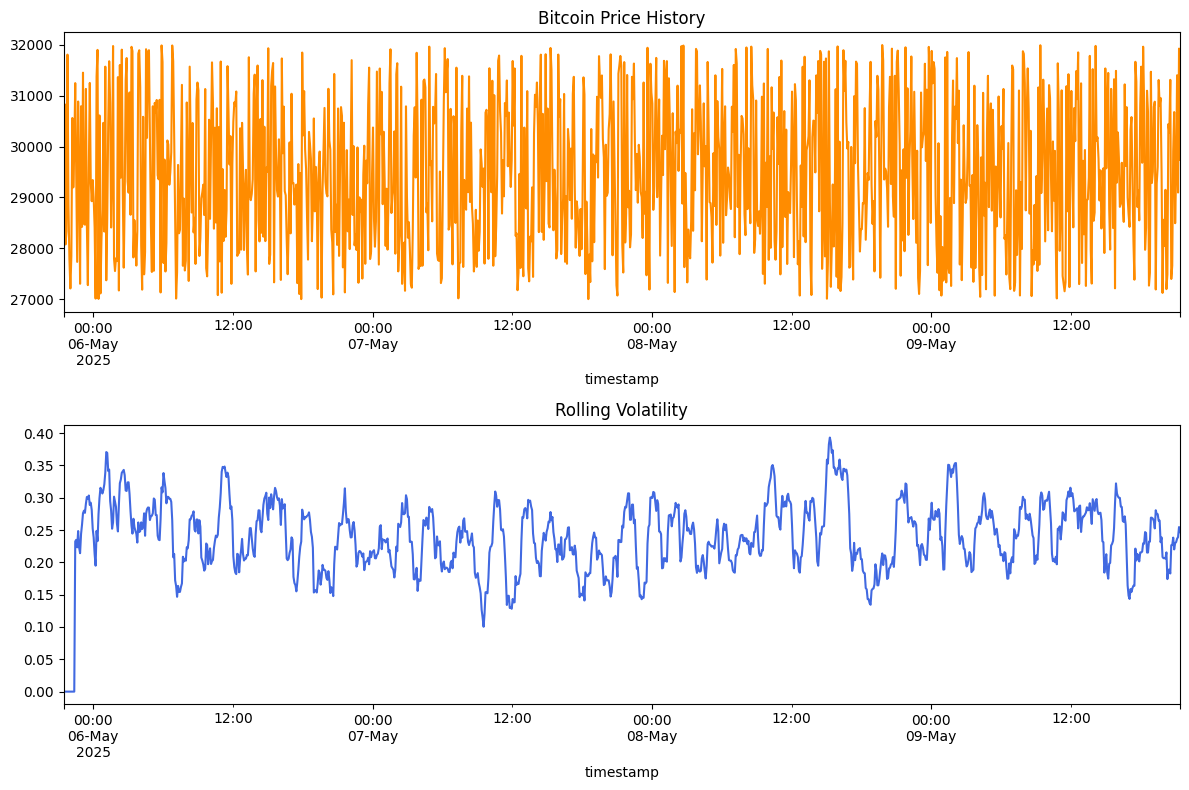

In [8]:
# Generate analysis
metrics = analyze_data(full_df)

# Plot price and volatility
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
full_df.set_index('timestamp')['price'].plot(
    ax=ax[0], 
    title='Bitcoin Price History',
    color='darkorange'
)
full_df.set_index('timestamp')['volatility'].plot(
    ax=ax[1],
    title='Rolling Volatility',
    color='royalblue'
)
plt.tight_layout()
plt.show()

In [9]:
df = add_technical_indicators(full_df)

In [10]:
# Ensure the timestamp column is set as the index
df = full_df.set_index('timestamp')

# Perform time series analysis
analysis = analyze_time_series(df)

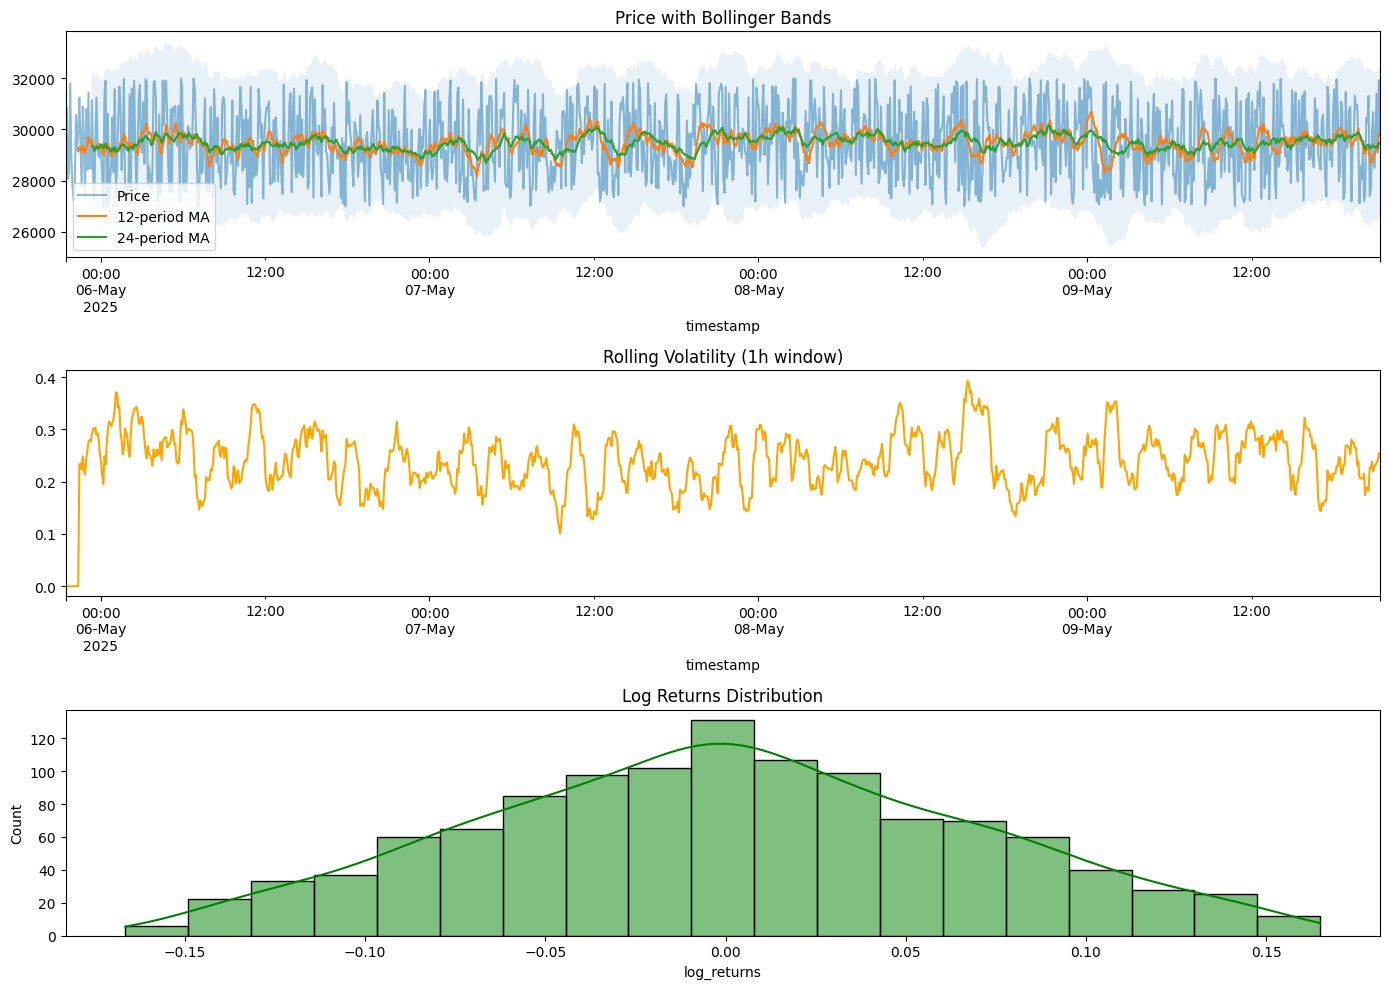

In [11]:
create_analysis_plots(df)

In [12]:
print_statistical_summary(df)

Price Statistics:
count     1152.000000
mean     29465.706198
std       1437.884980
min      27000.930000
25%      28243.637500
50%      29368.750000
75%      30748.515000
max      31994.180000
Name: price, dtype: float64

Volatility Statistics:
count    1152.000000
mean        0.239074
std         0.054776
min         0.000000
25%         0.205605
50%         0.239176
75%         0.276089
max         0.393117
Name: volatility, dtype: float64

Correlation Matrix:
               price  volatility
price       1.000000    0.042441
volatility  0.042441    1.000000

Normality Tests:
Price Jarque-Bera: SignificanceResult(statistic=np.float64(69.15735658060132), pvalue=np.float64(9.60883701649285e-16))
Returns Shapiro: ShapiroResult(statistic=np.float64(0.9935771481509557), pvalue=np.float64(7.142606908191516e-05))


In [13]:
print("\nPrice Outliers:")
print(detect_outliers(df))


Price Outliers:
Empty DataFrame
Columns: [price, volatility, log_returns, MA_12, MA_24, Upper_BB, Lower_BB, High_Vol]
Index: []


## Interactive Q&A System
Predefined example questions with enhanced output

In [14]:
questions = [
    "What was the highest price in the last 6 hours?",
    "Show me times when volatility spiked",
    "What's the current price trend?",
    "Exit"
]

for idx, question in enumerate(questions, 1):
    clear_output(wait=True)
    print(f"Question {idx}/{len(questions)}")
    print("="*30)
    
    if question == "Exit":
        break
        
    # Create context from data
    context = ""
    if "price" in question.lower():
        context = f"Recent Bitcoin prices:\n{full_df[['timestamp', 'price']].tail(12).to_string()}"
    elif "volatility" in question.lower():
        context = f"Volatility anomalies:\n{metrics['recent_anomalies'].tail(3).to_string()}"
    
    # Get answer with context
    answer = handle_query(llm, f"{context}\n{question}")
    
    # Print formatted output
    print(f"\nQ: {question}")
    print(f"\nA: {answer}\n")
    
    # Show supporting data
    if context:
        print("\nSupporting Data:")
        print(context)
    
    if idx < len(questions):
        input("\nPress Enter to continue...")


Question 4/4


## Advanced Query Demonstration
Custom question input with data context

In [15]:
run_bitcoin_chatbot(llm, full_df)

Bitcoin Data Chatbot



Llama.generate: 1 prefix-match hit, remaining 884 prompt tokens to eval
llama_perf_context_print:        load time =    8276.78 ms
llama_perf_context_print: prompt eval time =   13417.95 ms /   884 tokens (   15.18 ms per token,    65.88 tokens per second)
llama_perf_context_print:        eval time =    1878.06 ms /    27 runs   (   69.56 ms per token,    14.38 tokens per second)
llama_perf_context_print:       total time =   15299.70 ms /   911 tokens



You: what is the average bitcoin price in past 2 days


Assistant: The average Bitcoin price in the past 2 days is 29465.706198.



Llama.generate: 912 prefix-match hit, remaining 21 prompt tokens to eval
llama_perf_context_print:        load time =    8276.78 ms
llama_perf_context_print: prompt eval time =     747.16 ms /    21 tokens (   35.58 ms per token,    28.11 tokens per second)
llama_perf_context_print:        eval time =    1495.88 ms /    21 runs   (   71.23 ms per token,    14.04 tokens per second)
llama_perf_context_print:       total time =    2245.56 ms /    42 tokens



You: compare it with the current bitcoin pice


Assistant: The current Bitcoin price is 29368.750000.



Llama.generate: 954 prefix-match hit, remaining 19 prompt tokens to eval
llama_perf_context_print:        load time =    8276.78 ms
llama_perf_context_print: prompt eval time =     675.34 ms /    19 tokens (   35.54 ms per token,    28.13 tokens per second)
llama_perf_context_print:        eval time =    4574.05 ms /    64 runs   (   71.47 ms per token,    13.99 tokens per second)
llama_perf_context_print:       total time =    5256.63 ms /    83 tokens



You: compare it with current bitcoin price


Assistant: The difference between the current Bitcoin price and the average Bitcoin price in the past 2 days is 29368.750000 - 29465.706198 = -1087.054972.

Exiting the Bitcoin Q&A bot. Goodbye!
